<a href="https://colab.research.google.com/github/krishgupta1843-star/project-beach/blob/main/HousePricePrediction_py.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler, MinMaxScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)



All libraries imported successfully!


In [ ]:

df = pd.read_csv("train.csv")
print("First 5 rows of the dataset:")
display(df.head())
print("\nLast 5 rows of the dataset:")
display(df.tail())
print(f"\nDataset Shape: {df.shape[0]} rows and {df.shape[1]} columns")
print("\nColumn Names:")
print(df.columns.tolist())
print("\nData Types of Each Column:")
print(df.dtypes)


First 5 rows of the dataset:


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000



Last 5 rows of the dataset:


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
1455,1456,60,RL,62.0,7917,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,8,2007,WD,Normal,175000
1456,1457,20,RL,85.0,13175,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,2,2010,WD,Normal,210000
1457,1458,70,RL,66.0,9042,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,GdPrv,Shed,2500,5,2010,WD,Normal,266500
1458,1459,20,RL,68.0,9717,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,142125
1459,1460,20,RL,75.0,9937,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,6,2008,WD,Normal,147500



Dataset Shape: 1460 rows and 81 columns

Column Names:
['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1', 'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual', 'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType', 'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual', 'GarageCond', 'PavedDrive', 'WoodDeckSF', 'OpenPorchSF', 'Enclosed

In [ ]:
df.info()
print("\n=== Statistical Summary (All Columns) ===")
display(df.describe(include='all').T)
print("\n=== Missing Values per Column (only columns with missing data) ===")
missing_counts = df.isnull().sum()
print(missing_counts[missing_counts > 0].sort_values(ascending=False))
print("\n=== Missing Value Percentage (only columns with missing data) ===")
missing_pct = (df.isnull().sum() / len(df)) * 100
print(missing_pct[missing_pct > 0].sort_values(ascending=False).round(2))
print(f"\n=== Duplicate Rows ===\nNumber of duplicate rows: {df.duplicated().sum()}")
print("\n=== Unique Values per Column ===")
print(df.nunique().sort_values(ascending=False))
print(f"\n=== Memory Usage ===")
print(f"Total memory used by dataset: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")


=== DataFrame Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null 

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Id,1460.0,NaN,NaN,NaN,730.5,421.610009,1.0,365.75,730.5,1095.25,1460.0
MSSubClass,1460.0,NaN,NaN,NaN,56.89726,42.300571,20.0,20.0,50.0,70.0,190.0
MSZoning,1460,5,RL,1151,NaN,NaN,NaN,NaN,NaN,NaN,NaN
LotFrontage,1201.0,NaN,NaN,NaN,70.049958,24.284752,21.0,59.0,69.0,80.0,313.0
LotArea,1460.0,NaN,NaN,NaN,10516.828082,9981.264932,1300.0,7553.5,9478.5,11601.5,215245.0
...,...,...,...,...,...,...,...,...,...,...,...
MoSold,1460.0,NaN,NaN,NaN,6.321918,2.703626,1.0,5.0,6.0,8.0,12.0
YrSold,1460.0,NaN,NaN,NaN,2007.815753,1.328095,2006.0,2007.0,2008.0,2009.0,2010.0
SaleType,1460,9,WD,1267,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SaleCondition,1460,6,Normal,1198,NaN,NaN,NaN,NaN,NaN,NaN,NaN



=== Missing Values per Column (only columns with missing data) ===
PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
BsmtExposure      38
BsmtFinType2      38
BsmtQual          37
BsmtCond          37
BsmtFinType1      37
MasVnrArea         8
Electrical         1
dtype: int64

=== Missing Value Percentage (only columns with missing data) ===
PoolQC          99.52
MiscFeature     96.30
Alley           93.77
Fence           80.75
MasVnrType      59.73
FireplaceQu     47.26
LotFrontage     17.74
GarageType       5.55
GarageYrBlt      5.55
GarageFinish     5.55
GarageQual       5.55
GarageCond       5.55
BsmtExposure     2.60
BsmtFinType2     2.60
BsmtQual         2.53
BsmtCond         2.53
BsmtFinType1     2.53
MasVnrArea       0.55
Electrical       0.07
dtype: float64

=== Duplicate Rows 

In [ ]:
df_clean = df.copy()
missing_pct = (df_clean.isnull().sum() / len(df_clean)) * 100
cols_to_drop = missing_pct[missing_pct > 20].index.tolist()
print("=== Rule 1: Columns Removed (More Than 20% Missing) ===")
for col in cols_to_drop:
    print(f"  - {col}: {missing_pct[col]:.2f}% missing -> REMOVED")
df_clean.drop(columns=cols_to_drop, inplace=True)
print(f"\nTotal columns removed: {len(cols_to_drop)}")
print(f"Remaining columns: {df_clean.shape[1]}")
num_cols = df_clean.select_dtypes(include=[np.number]).columns
cat_cols = df_clean.select_dtypes(include=['object']).columns
print("\n=== Rule 2: Filling Remaining Missing Values ===")
for col in num_cols:
    if df_clean[col].isnull().sum() > 0:
        median_val = df_clean[col].median()
        df_clean[col] = df_clean[col].fillna(median_val)
        print(f"  - Numeric column '{col}' filled with median: {median_val}")
for col in cat_cols:
    if df_clean[col].isnull().sum() > 0:
        mode_val = df_clean[col].mode()[0]
        df_clean[col] = df_clean[col].fillna(mode_val)
        print(f"  - Categorical column '{col}' filled with mode: '{mode_val}'")
before_rows = df_clean.shape[0]
df_clean.drop_duplicates(inplace=True)
after_rows = df_clean.shape[0]
print(f"\n=== Rule 3: Duplicate Rows Removed ===")
print(f"Removed {before_rows - after_rows} duplicate rows")
df_clean.columns = (
    df_clean.columns
    .str.strip()
    .str.lower()
    .str.replace(' ', '_')
    .str.replace(r'[^a-z0-9_]', '', regex=True)
)
print("\n=== Rule 4: Standardized Column Names (sample) ===")
print(df_clean.columns.tolist()[:10], "...")


cat_cols = df_clean.select_dtypes(include=['object']).columns
for col in cat_cols:
    df_clean[col] = df_clean[col].astype(str).str.strip()
print("\n=== Rule 5: Stripped leading/trailing spaces from categorical values ===")


print("\n=== Rule 6: Final Missing Value Report ===")
final_missing = df_clean.isnull().sum()
print(f"Total remaining missing values: {final_missing.sum()}")
if final_missing.sum() == 0:
    print("SUCCESS: No missing values remain in the dataset.")


=== Rule 1: Columns Removed (More Than 20% Missing) ===
  - Alley: 93.77% missing -> REMOVED
  - MasVnrType: 59.73% missing -> REMOVED
  - FireplaceQu: 47.26% missing -> REMOVED
  - PoolQC: 99.52% missing -> REMOVED
  - Fence: 80.75% missing -> REMOVED
  - MiscFeature: 96.30% missing -> REMOVED

Total columns removed: 6
Remaining columns: 75

=== Rule 2: Filling Remaining Missing Values ===
  - Numeric column 'LotFrontage' filled with median: 69.0
  - Numeric column 'MasVnrArea' filled with median: 0.0
  - Numeric column 'GarageYrBlt' filled with median: 1980.0
  - Categorical column 'BsmtQual' filled with mode: 'TA'
  - Categorical column 'BsmtCond' filled with mode: 'TA'
  - Categorical column 'BsmtExposure' filled with mode: 'No'
  - Categorical column 'BsmtFinType1' filled with mode: 'Unf'
  - Categorical column 'BsmtFinType2' filled with mode: 'Unf'
  - Categorical column 'Electrical' filled with mode: 'SBrkr'
  - Categorical column 'GarageType' filled with mode: 'Attchd'
  - Cate

In [ ]:
removed_cols = []
id_like_cols = [col for col in df_clean.columns if 'id' == col.lower() or col.lower().endswith('_id')]
for col in id_like_cols:
    if df_clean[col].nunique() == len(df_clean):
        df_clean.drop(columns=[col], inplace=True)
        removed_cols.append((col, "Identifier column - unique per row, no predictive value"))


duplicate_cols = []
cols = df_clean.columns
for i in range(len(cols)):
    for j in range(i + 1, len(cols)):
        if df_clean[cols[i]].equals(df_clean[cols[j]]):
            duplicate_cols.append(cols[j])

for col in set(duplicate_cols):
    if col in df_clean.columns:
        df_clean.drop(columns=[col], inplace=True)
        removed_cols.append((col, "Exact duplicate of another column"))


num_df = df_clean.select_dtypes(include=[np.number])
corr_matrix = num_df.corr().abs()
upper_triangle = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

high_corr_pairs = [(col, row) for col in upper_triangle.columns for row in upper_triangle.index
                    if upper_triangle.loc[row, col] > 0.95]

for col, row in high_corr_pairs:

    if col in df_clean.columns and row in df_clean.columns and 'saleprice' in df_clean.columns:
        corr_col = abs(df_clean[col].corr(df_clean['saleprice']))
        corr_row = abs(df_clean[row].corr(df_clean['saleprice']))
        drop_col = col if corr_col < corr_row else row
        if drop_col in df_clean.columns:
            df_clean.drop(columns=[drop_col], inplace=True)
            removed_cols.append((drop_col, f"Highly correlated (r>0.95) with '{row if drop_col==col else col}'"))


if removed_cols:
    print("=== Redundant Columns Removed ===")
    for col, reason in removed_cols:
        print(f"  - '{col}' removed. Reason: {reason}")
else:
    print("No redundant columns were found in the dataset.")

print(f"\nRemaining columns after redundancy check: {df_clean.shape[1]}")


=== Redundant Columns Removed ===
  - 'id' removed. Reason: Identifier column - unique per row, no predictive value

Remaining columns after redundancy check: 74


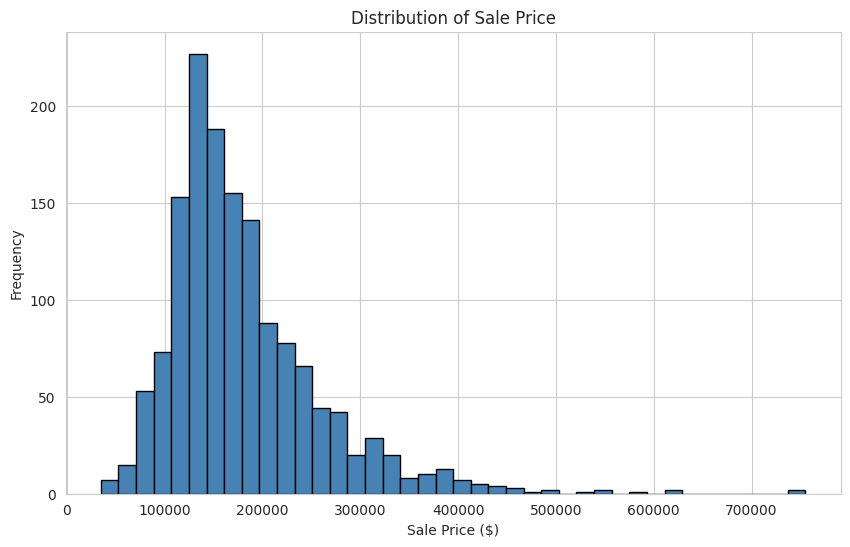

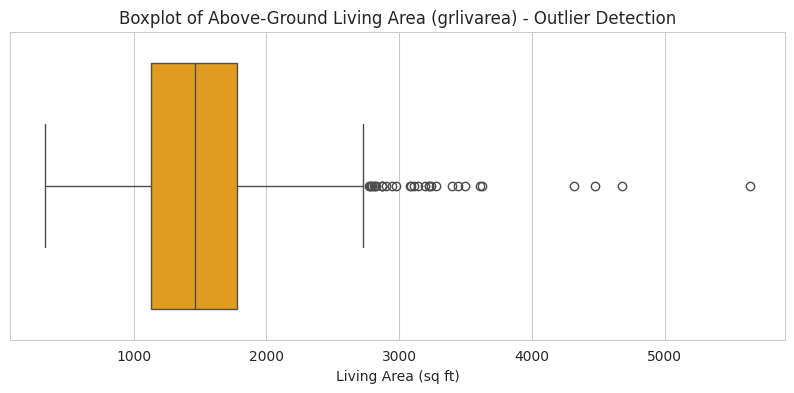

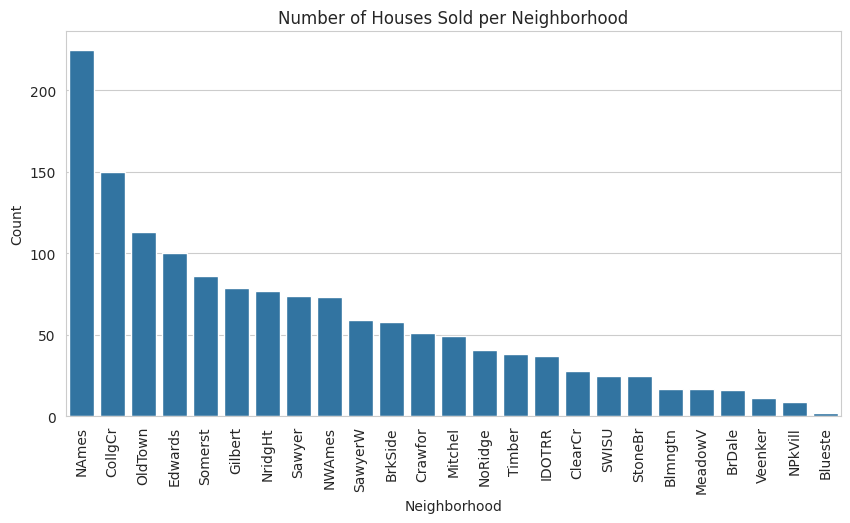

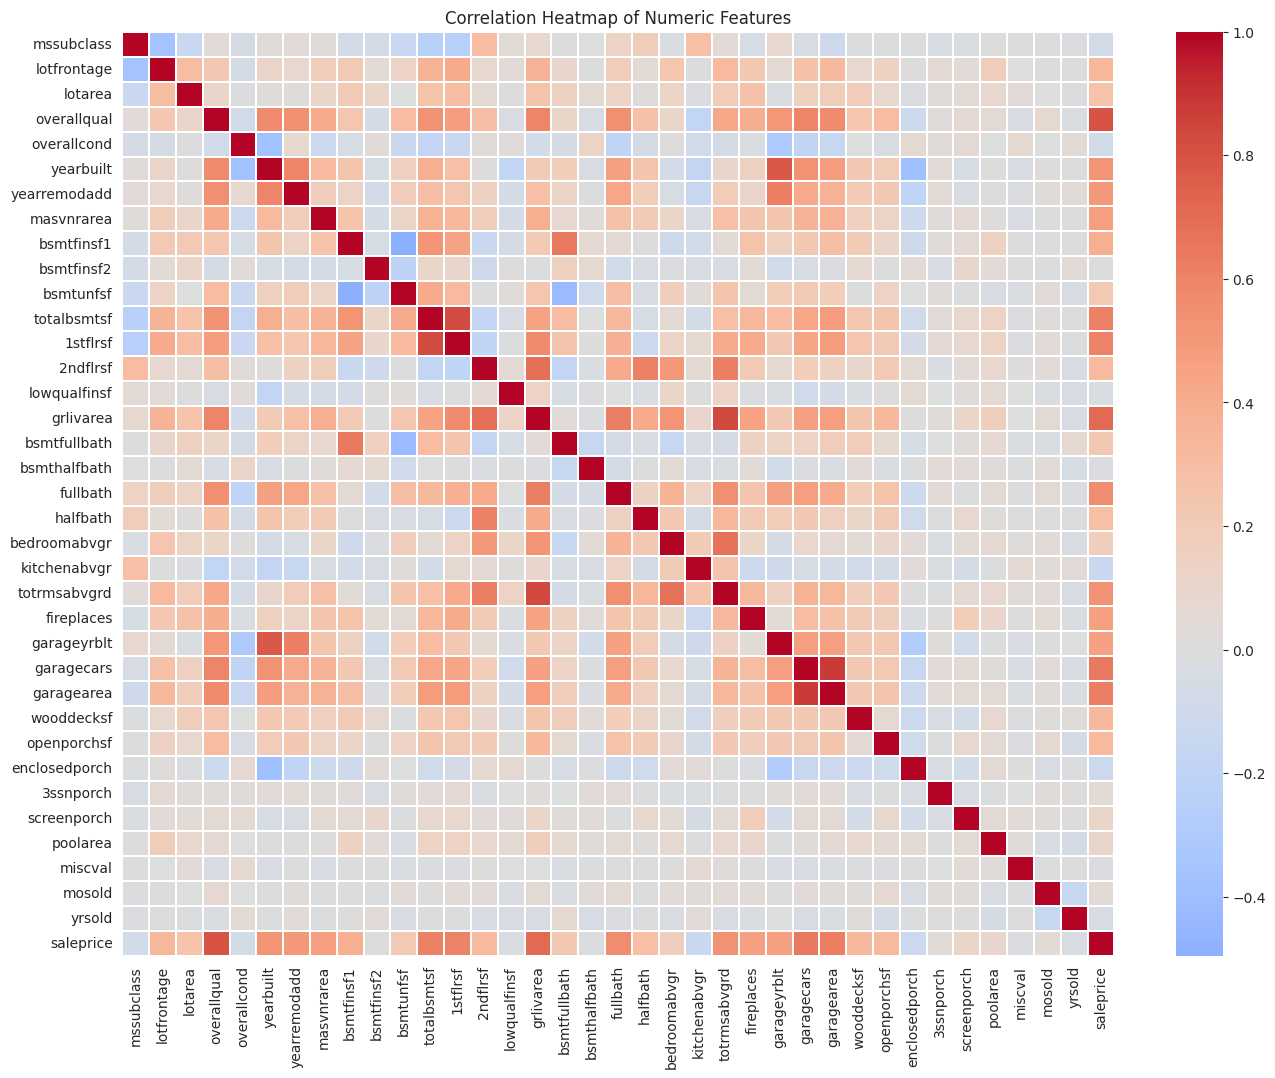

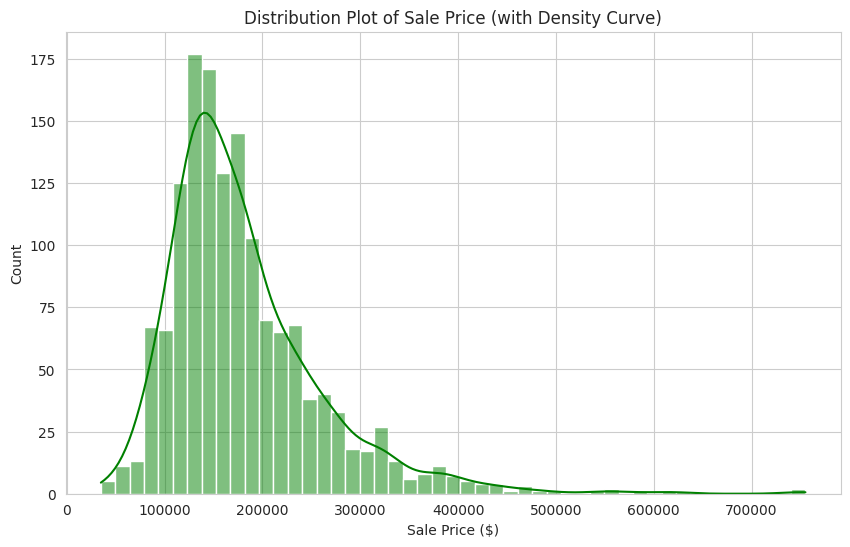

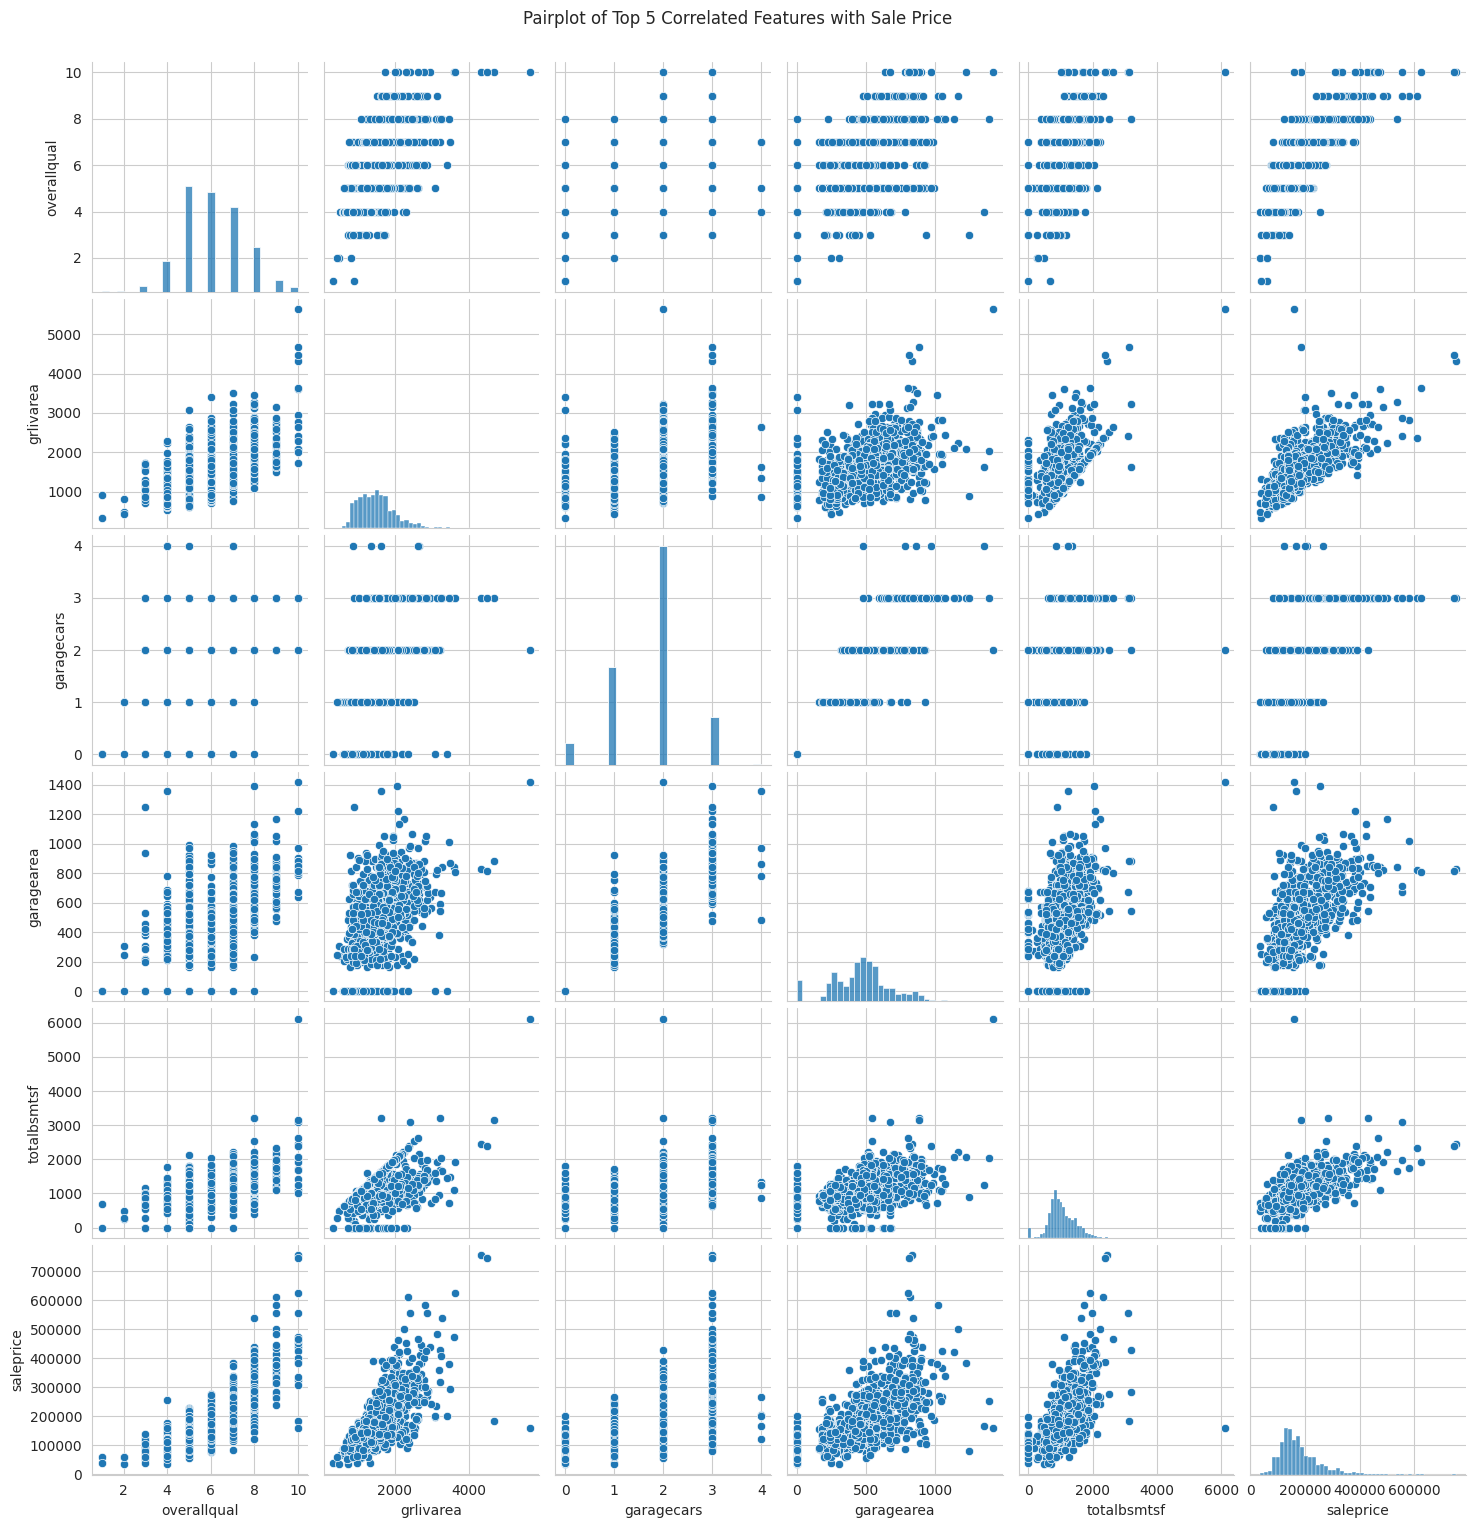

Top 5 features most correlated with SalePrice:
saleprice      1.000000
overallqual    0.790982
grlivarea      0.708624
garagecars     0.640409
garagearea     0.623431
totalbsmtsf    0.613581
Name: saleprice, dtype: float64


In [ ]:

plt.figure(figsize=(10, 6))
plt.hist(df_clean['saleprice'], bins=40, color='steelblue', edgecolor='black')
plt.title('Distribution of Sale Price')
plt.xlabel('Sale Price ($)')
plt.ylabel('Frequency')
plt.show()


plt.figure(figsize=(10, 4))
sns.boxplot(x=df_clean['grlivarea'], color='orange')
plt.title('Boxplot of Above-Ground Living Area (grlivarea) - Outlier Detection')
plt.xlabel('Living Area (sq ft)')
plt.show()
plt.figure(figsize=(10, 5))
sns.countplot(data=df_clean, x='neighborhood', order=df_clean['neighborhood'].value_counts().index)
plt.title('Number of Houses Sold per Neighborhood')
plt.xticks(rotation=90)
plt.xlabel('Neighborhood')
plt.ylabel('Count')
plt.show()
plt.figure(figsize=(16, 12))
numeric_df = df_clean.select_dtypes(include=[np.number])
corr = numeric_df.corr()
sns.heatmap(corr, cmap='coolwarm', center=0, linewidths=0.3)
plt.title('Correlation Heatmap of Numeric Features')
plt.show()
plt.figure(figsize=(10, 6))
sns.histplot(df_clean['saleprice'], kde=True, color='green')
plt.title('Distribution Plot of Sale Price (with Density Curve)')
plt.xlabel('Sale Price ($)')
plt.show()
top_corr_features = corr['saleprice'].abs().sort_values(ascending=False).index[1:6]
sns.pairplot(df_clean[list(top_corr_features) + ['saleprice']])
plt.suptitle('Pairplot of Top 5 Correlated Features with Sale Price', y=1.02)
plt.show()

print("Top 5 features most correlated with SalePrice:")
print(corr['saleprice'].abs().sort_values(ascending=False).head(6))


In [ ]:

df_clean['house_age'] = df_clean['yrsold'] - df_clean['yearbuilt']
df_clean['remod_age'] = df_clean['yrsold'] - df_clean['yearremodadd']


df_clean['house_age'] = df_clean['house_age'].clip(lower=0)
df_clean['remod_age'] = df_clean['remod_age'].clip(lower=0)


df_clean.drop(columns=['yearbuilt', 'yearremodadd'], inplace=True)

print("New features created: 'house_age' and 'remod_age'")
print(df_clean[['house_age', 'remod_age']].describe())


New features created: 'house_age' and 'remod_age'
         house_age    remod_age
count  1460.000000  1460.000000
mean     36.547945    22.950685
std      30.250152    20.639875
min       0.000000     0.000000
25%       8.000000     4.000000
50%      35.000000    14.000000
75%      54.000000    41.000000
max     136.000000    60.000000


In [ ]:

y = df_clean['saleprice']


X = df_clean.drop(columns=['saleprice'])

print(f"Features (X) shape: {X.shape}")
print(f"Target (y) shape: {y.shape}")
print(f"\nTarget variable preview:\n{y.head()}")


Features (X) shape: (1460, 73)
Target (y) shape: (1460,)

Target variable preview:
0    208500
1    181500
2    223500
3    140000
4    250000
Name: saleprice, dtype: int64


In [ ]:

categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
print(f"Total categorical columns to encode: {len(categorical_cols)}")
binary_cols = [col for col in categorical_cols if X[col].nunique() == 2]
nominal_cols = [col for col in categorical_cols if X[col].nunique() > 2]

print(f"Binary columns (Label Encoding): {binary_cols}")
print(f"Nominal columns (One-Hot Encoding): {len(nominal_cols)} columns")


le = LabelEncoder()
for col in binary_cols:
    X[col] = le.fit_transform(X[col])


X = pd.get_dummies(X, columns=nominal_cols, drop_first=True)

print(f"\nShape of X after encoding: {X.shape}")
print("Encoding complete. All columns are now numeric.")
print(f"\nRemaining non-numeric columns: {X.select_dtypes(include=['object']).columns.tolist()}")


Total categorical columns to encode: 37
Binary columns (Label Encoding): ['street', 'utilities', 'centralair']
Nominal columns (One-Hot Encoding): 34 columns

Shape of X after encoding: (1460, 229)
Encoding complete. All columns are now numeric.

Remaining non-numeric columns: []


In [ ]:

original_numeric_cols = df_clean.select_dtypes(include=[np.number]).columns.tolist()
original_numeric_cols = [col for col in original_numeric_cols if col != 'saleprice' and col in X.columns]

print(f"Numeric columns to scale: {len(original_numeric_cols)}")


scaler = StandardScaler()
X_scaled = X.copy()
X_scaled[original_numeric_cols] = scaler.fit_transform(X[original_numeric_cols])

print("\nSample of scaled numeric features (mean ~0, std ~1):")
display(X_scaled[original_numeric_cols].describe().T[['mean', 'std']].head())


Numeric columns to scale: 36

Sample of scaled numeric features (mean ~0, std ~1):


,mean,std
mssubclass,-8.455945e-17,1.000343
lotfrontage,2.798370e-16,1.000343
lotarea,-5.840077e-17,1.000343
overallqual,1.387018e-16,1.000343
overallcond,3.540547e-16,1.000343


In [ ]:


X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

print(f"Training set size: {X_train.shape[0]} rows ({X_train.shape[0]/len(X_scaled)*100:.1f}%)")
print(f"Testing set size: {X_test.shape[0]} rows ({X_test.shape[0]/len(X_scaled)*100:.1f}%)")
print(f"Number of features: {X_train.shape[1]}")


Training set size: 1168 rows (80.0%)
Testing set size: 292 rows (20.0%)
Number of features: 229


In [ ]:
models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree Regressor": DecisionTreeRegressor(random_state=42),
    "Random Forest Regressor": RandomForestRegressor(random_state=42, n_estimators=200),
    "KNN Regressor": KNeighborsRegressor(n_neighbors=5),
    "SVR": SVR(kernel='rbf')
}

trained_models = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    trained_models[name] = model
    print(f"Trained: {name}")

print("\nAll 5 models trained successfully!")


Trained: Linear Regression
Trained: Decision Tree Regressor
Trained: Random Forest Regressor
Trained: KNN Regressor
Trained: SVR

All 5 models trained successfully!


In [ ]:
results = []

for name, model in trained_models.items():
    y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    results.append({
        "Model": name,
        "MAE": round(mae, 2),
        "MSE": round(mse, 2),
        "RMSE": round(rmse, 2),
        "R2 Score": round(r2, 4)
    })

results_df = pd.DataFrame(results).sort_values(by="R2 Score", ascending=False).reset_index(drop=True)

print("=== Model Comparison Table ===")
display(results_df)

best_model_name = results_df.iloc[0]["Model"]
best_model = trained_models[best_model_name]
print(f"\nBest performing model: {best_model_name}")
print(f"R2 Score: {results_df.iloc[0]['R2 Score']}  |  RMSE: ${results_df.iloc[0]['RMSE']:,.2f}")


=== Model Comparison Table ===


,Model,MAE,MSE,RMSE,R2 Score
0,Random Forest Regressor,17599.68,8.201924e+08,28639.00,0.8931
1,KNN Regressor,21675.09,1.437965e+09,37920.51,0.8125
2,Decision Tree Regressor,26279.64,1.703095e+09,41268.57,0.7780
3,Linear Regression,20389.12,2.701133e+09,51972.42,0.6478
4,SVR,59512.94,7.854277e+09,88624.36,-0.0240



Best performing model: Random Forest Regressor
R2 Score: 0.8931  |  RMSE: $28,639.00


In [ ]:


y_pred_best = best_model.predict(X_test)

comparison_df = pd.DataFrame({
    "Actual Price": y_test.values,
    "Predicted Price": np.round(y_pred_best, 2)
})
comparison_df["Difference"] = comparison_df["Actual Price"] - comparison_df["Predicted Price"]

print(f"First 10 Predictions using {best_model_name}:")
display(comparison_df.head(10))


First 10 Predictions using Random Forest Regressor:


,Actual Price,Predicted Price,Difference
0,154500,141717.75,12782.25
1,325000,317870.54,7129.46
2,115000,115687.38,-687.38
3,159000,155102.04,3897.96
4,315500,328719.47,-13219.47
5,75500,85969.92,-10469.92
6,311500,208835.74,102664.26
7,146000,151769.98,-5769.98
8,84500,86658.92,-2158.92
9,135500,128343.14,7156.86


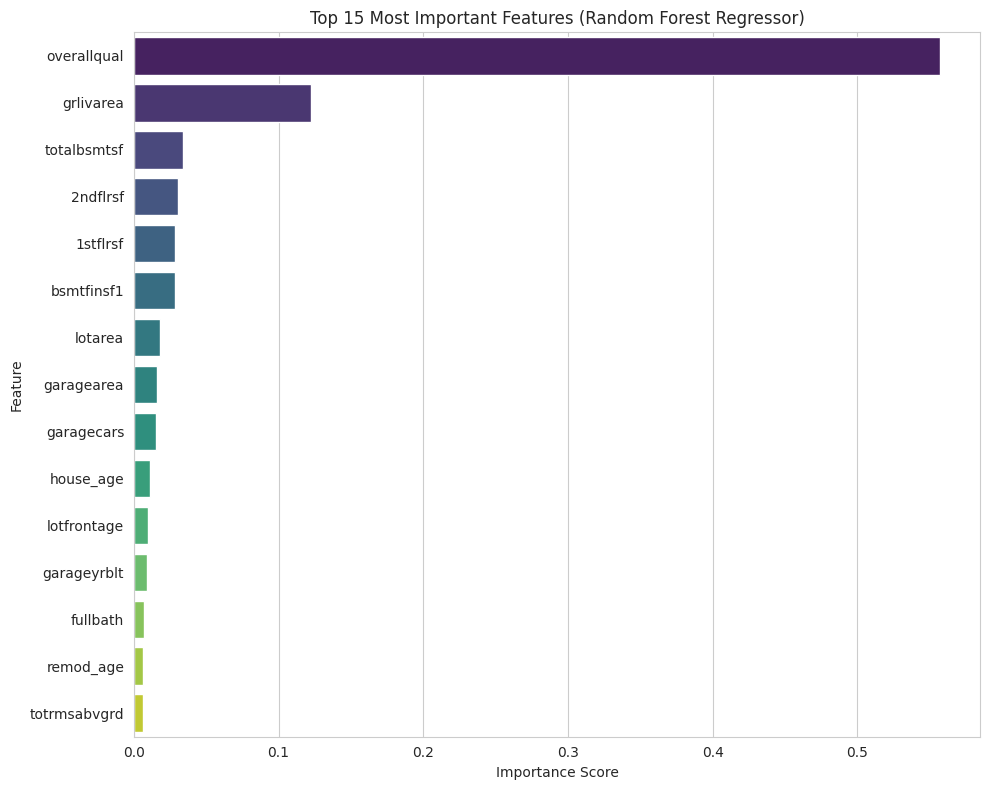

Top 5 most important features:
overallqual    0.556818
grlivarea      0.122164
totalbsmtsf    0.033843
2ndflrsf       0.030307
1stflrsf       0.028383
dtype: float64


In [ ]:
if hasattr(best_model, "feature_importances_"):
    importances = pd.Series(best_model.feature_importances_, index=X_train.columns)
    top_features = importances.sort_values(ascending=False).head(15)

    plt.figure(figsize=(10, 8))
    sns.barplot(x=top_features.values, y=top_features.index, palette="viridis")
    plt.title(f"Top 15 Most Important Features ({best_model_name})")
    plt.xlabel("Importance Score")
    plt.ylabel("Feature")
    plt.tight_layout()
    plt.show()

    print("Top 5 most important features:")
    print(top_features.head(5))
else:
    print(f"{best_model_name} does not support feature importance directly (e.g. Linear Regression, KNN, or SVR).")
    print("Feature importance is only available for tree-based models like Decision Tree or Random Forest.")


In [ ]:

joblib.dump(best_model, "best_house_price_model.pkl")
joblib.dump(scaler, "feature_scaler.pkl")

print(f"Model saved as 'best_house_price_model.pkl' (Model used: {best_model_name})")
print("Scaler saved as 'feature_scaler.pkl'")
print("\nTo reuse this model later:")
print("  model = joblib.load('best_house_price_model.pkl')")
print("  scaler = joblib.load('feature_scaler.pkl')")


Model saved as 'best_house_price_model.pkl' (Model used: Random Forest Regressor)
Scaler saved as 'feature_scaler.pkl'

To reuse this model later:
  model = joblib.load('best_house_price_model.pkl')
  scaler = joblib.load('feature_scaler.pkl')
